# Aplicação e Análise Comparativa de Métodos Numéricos

## Determinação da altura inicial de uma coluna de água

**Instituição:** Universidade Católica de Pernambuco — UNICAP  
**Curso:** Ciência da Computação  
**Disciplina:** Métodos Numéricos  
**Ano/Semestre:** 2026.2  

Este notebook apresenta a formulação matemática do problema, os cálculos auxiliares, a aplicação dos métodos numéricos, as tabelas de iteração, os gráficos e a análise comparativa dos resultados.

As implementações dos métodos de **Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante não estão neste notebook**. Elas são importadas do pacote Python do projeto, localizado em `src/metodos_numericos/`, conforme solicitado no enunciado da atividade.

# SUMÁRIO

1. [Formulação matemática e definição dos critérios numéricos](#formulacao)
   1. [Formulação do problema](#formulacao-problema)
   2. [Transformação para a forma \(f(H)=0\)](#transformacao)
   3. [Domínio, continuidade e intervalo inicial](#dominio)
   4. [Verificação da unicidade](#unicidade)
   5. [Critérios de parada](#criterios)
   6. [Escolha das tolerâncias](#tolerancias)
   7. [Critério adicional para o Método da Bisseção](#criterio)
   8. [Limite máximo de iterações](#limite)
   9. [Dados utilizados na análise comparativa](#dados-comparacao)
2. [Preparação computacional](#preparacao)
3. [Aplicação dos métodos numéricos](#aplicacao)
   1. [Ponto Fixo](#ponto-fixo)
   2. [Bisseção](#bissecao)
   3. [Falsa Posição](#falsa-posicao)
   4. [Newton-Raphson](#newton)
   5. [Secante](#secante)
4. [Tabela comparativa](#tabela-comparativa)
5. [Gráficos comparativos](#graficos)
6. [Análise comparativa](#analise)
7. [Conclusão](#conclusao)
8. [Referências](#referencias)

<a id="formulacao"></a>
# FORMULAÇÃO MATEMÁTICA E DEFINIÇÃO DOS CRITÉRIOS NUMÉRICOS

<a id="formulacao-problema"></a>

## 1. Formulação do problema

O problema analisado consiste em determinar a altura inicial $H$ da coluna de água necessária para que o escoamento através de um tubo alcance a velocidade de $5\,m/s$ após $2{,}5\,s$. A velocidade é descrita pelo modelo:

$$
v =
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]
$$

em que $v$ representa a velocidade da água, $g$ a aceleração da gravidade, $H$ a altura inicial da coluna de água, $L$ o comprimento do tubo e $t$ o tempo.

Para as condições estabelecidas no problema:

$$
g = 9{,}81\,m/s^2,
\qquad
L = 4\,m,
\qquad
t = 2{,}5\,s,
\qquad
v = 5\,m/s
$$

A equação apresenta caráter não linear, pois a incógnita $H$ aparece simultaneamente em uma raiz quadrada e no argumento de uma função hiperbólica.

Na literatura de análise numérica, a determinação de raízes de equações não lineares é usualmente tratada mediante a formulação $f(x)=0$. Igarashi (1985a) discute a solução numérica de equações não lineares nessa forma, incluindo precisão e critérios práticos de término. Sikorski e Woźniakowski (1986) analisam formalmente diferentes critérios de erro para equações escalares não lineares. Brent (1971) aborda a localização de zeros a partir de um intervalo no qual a função muda de sinal.

Considerando essas abordagens, neste trabalho o problema será formulado como uma equação do tipo $f(H)=0$, permitindo aplicar diferentes métodos numéricos à mesma função.

<a id="transformacao"></a>

## 2. Transformação para a forma $f(H)=0$

Substituindo a velocidade requerida, $v=5\,m/s$, no modelo original:

$$
5 =
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]
$$

Reunindo todos os termos em um único membro:

$$
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]-5=0
$$

Define-se:

$$
f(H)=
\sqrt{2gH}\cdot
\tanh\left[
\left(\frac{\sqrt{2gH}}{2L}\right)t
\right]-5
$$

Essa transformação preserva o problema físico original, pois:

$$
f(H)=v(H)-5
$$

Portanto, uma raiz $H^*$ que satisfaça $f(H^*)=0$ corresponde exatamente a uma altura para a qual $v(H^*)=5\,m/s$.

Substituindo $g=9{,}81$, $L=4$ e $t=2{,}5$:

$$
f(H)=
\sqrt{2(9{,}81)H}\cdot
\tanh\left[
\frac{2{,}5\sqrt{2(9{,}81)H}}{2(4)}
\right]-5
$$

Como $2(9{,}81)=19{,}62$ e $2(4)=8$, a função de referência utilizada será:

$$
\boxed{
f(H)=
\sqrt{19{,}62H}\cdot
\tanh\left[
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right]-5
}
$$

<a id="preparacao"></a>
# 2. PREPARAÇÃO COMPUTACIONAL

A célula seguinte importa apenas bibliotecas auxiliares e as funções dos métodos numéricos implementadas no pacote `metodos_numericos`.

Antes de abrir o notebook, o projeto deve ser instalado a partir da raiz do repositório:

```bash
pip install -e .
```

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from metodos_numericos import (
    ponto_fixo,
    bissecao,
    falsa_posicao,
    newton_raphson,
    secante,
)

### Constantes e função residual


> **Importante:** A função \(f(H)\) pertence à formulação específica deste problema. Por isso ela é definida no notebook.

In [2]:
g = 9.81
L = 4.0
t = 2.5
v_alvo = 5.0

def f(H):
    return (
        math.sqrt(2 * g * H)
        * math.tanh((math.sqrt(2 * g * H) / (2 * L)) * t)
        - v_alvo
    )

<a id="dominio"></a>

## 3. Domínio, continuidade e escolha do intervalo inicial

Considerando:

$$
\boxed{
f(H)=
\sqrt{19{,}62H}\cdot
\tanh\left[
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right]-5
}
$$

A expressão contém o termo:

$$
\sqrt{19{,}62H}
$$

Para que a função permaneça no conjunto dos números reais:

$$
19{,}62H \geq 0
$$

Como $19{,}62 > 0$:

$$
\boxed{H \geq 0}
$$

Essa restrição matemática é coerente com a interpretação física da variável, pois $H$ representa uma altura de água.

No domínio $H \geq 0$, a raiz quadrada é contínua, a função $\tanh$ é contínua para todo argumento real e as operações de composição, produto e diferença preservam a continuidade. Logo, $f(H)$ é contínua no domínio físico considerado.

A escolha de um intervalo com mudança de sinal é central nos métodos de confinamento. Brent (1971) utiliza essa ideia para preservar a segurança do confinamento da raiz. Para a função específica deste problema, serão avaliados $H=1$ e $H=2$.

In [3]:
pontos = [0.0, 1.0, 2.0]

for H in pontos:
    print(f"f({H:.0f}) = {f(H):.12f}")

print()

if f(0) * f(2) < 0:
    print("Existe mudança de sinal no intervalo [0, 2].")

if f(1) * f(2) < 0:
    print("A raiz pode ser confinada no intervalo menor [1, 2].")

f(0) = -5.000000000000
f(1) = -1.093720547484
f(2) = 1.019273183590

Existe mudança de sinal no intervalo [0, 2].
A raiz pode ser confinada no intervalo menor [1, 2].


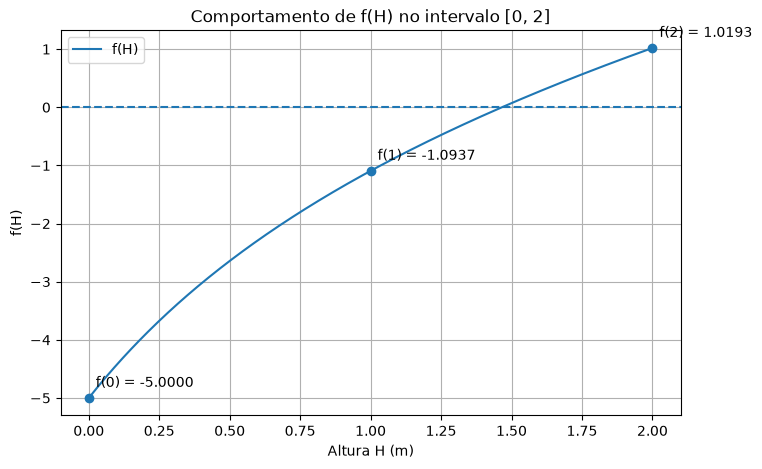

In [4]:
H_valores = np.linspace(0, 2, 400)

f_valores = [f(H) for H in H_valores]

plt.figure(figsize=(8, 5))

plt.plot(H_valores, f_valores, label="f(H)")

plt.axhline(0, linestyle="--")

# Pontos analisados
pontos_H = [0, 1, 2]
pontos_f = [f(H) for H in pontos_H]

plt.scatter(
    pontos_H,
    pontos_f,
    zorder=3
)

# Identificação dos pontos
for H in pontos_H:
    plt.annotate(
        f"f({H}) = {f(H):.4f}",
        (H, f(H)),
        xytext=(5, 8),
        textcoords="offset points"
    )

plt.xlabel("Altura H (m)")
plt.ylabel("f(H)")
plt.title("Comportamento de f(H) no intervalo [0, 2]")

plt.grid(True)
plt.legend()

plt.show()

Os valores obtidos são aproximadamente:

$$
f(1) \approx -1{,}093721 < 0
$$

e

$$
f(2) \approx 1{,}019273 > 0
$$

Consequentemente:

$$
f(1)\cdot f(2) < 0
$$

Como $f$ é contínua em $[1,2]$, existe pelo menos uma raiz $H^*$ no intervalo $(1,2)$. Por essa razão, adota-se:

$$
\boxed{[a,b]=[1,2]}
$$

como intervalo inicial para os métodos que exigem confinamento da raiz, particularmente Bisseção e Falsa Posição.

<a id="unicidade"></a>

## 4. Verificação da unicidade da solução

A mudança de sinal verificada no intervalo $[1,2]$ permite estabelecer a existência de pelo menos uma raiz, mas essa condição, isoladamente, não garante que a raiz seja única. Brent (1971), em seu trabalho sobre um algoritmo com convergência garantida para a determinação de zeros de funções, considera justamente o confinamento de uma raiz em um intervalo no qual a função apresenta mudança de sinal. Esse procedimento assegura a presença de um zero no intervalo sob as condições de continuidade, mas não implica, por si só, a unicidade da solução.

Para investigar a unicidade neste problema, analisa-se o comportamento da derivada de $f(H)$. Pelo resultado clássico de monotonicidade decorrente do Teorema do Valor Médio, se uma função diferenciável possui derivada estritamente positiva em um intervalo, então ela é estritamente crescente nesse intervalo. Assim, demonstrar que $f'(H)>0$ no domínio físico permite verificar que a função não pode assumir o valor zero em dois pontos distintos.

Considerando:

$$
f(H)=
\sqrt{2gH}\,
\tanh\left(
\frac{t\sqrt{2gH}}{2L}
\right)-5,
$$

define-se, para simplificar a expressão:

$$
z=
\frac{t\sqrt{2gH}}{2L}.
$$

A derivada da função pode então ser escrita como:

$$
f'(H)=
\frac{g}{\sqrt{2gH}}
\left[
\tanh(z)+
z\,\operatorname{sech}^2(z)
\right].
$$

Para $H>0$, tem-se:

$$
\frac{g}{\sqrt{2gH}}>0.
$$

Além disso, como $g>0$, $t>0$, $L>0$ e $H>0$, segue que:

$$
z=
\frac{t\sqrt{2gH}}{2L}>0.
$$

Para $z>0$, também são válidas as relações:

$$
\tanh(z)>0
$$

e

$$
\operatorname{sech}^2(z)>0.
$$

Como $z>0$, segue também que:

$$
z\,\operatorname{sech}^2(z)>0.
$$

Consequentemente, para $H>0$, o fator

$$
\frac{g}{\sqrt{2gH}}
$$

é positivo, assim como os dois termos presentes entre colchetes,

$$
\tanh(z)
\qquad\text{e}\qquad
z\,\operatorname{sech}^2(z).
$$

Portanto:

$$
\boxed{f'(H)>0\quad\text{para }H>0}.
$$

Logo, $f(H)$ é estritamente crescente no domínio físico $H>0$. Uma função estritamente crescente não pode assumir o mesmo valor em dois pontos distintos; em particular, não pode possuir duas raízes diferentes nesse domínio.

Como anteriormente foi verificada a existência de uma raiz no intervalo $(1,2)$ por meio da continuidade e da mudança de sinal, e agora foi demonstrado que $f(H)$ é estritamente crescente para $H>0$, conclui-se que essa raiz é única.

Assim:

$$
\boxed{\text{existe uma única raiz }H^*\in(1,2)}.
$$

In [5]:
def derivada_f(H):
    s = math.sqrt(2 * g * H)
    z = (t * s) / (2 * L)
    sech2 = 1 / (math.cosh(z) ** 2)

    return (g / s) * (
        math.tanh(z) + z * sech2
    )

for H in [1.0, 1.25, 1.50, 1.75, 2.0]:
    print(f"H = {H:.2f} -> f'(H) = {derivada_f(H):.12f}")

H = 1.00 -> f'(H) = 2.634542982328
H = 1.25 -> f'(H) = 2.317387695041
H = 1.50 -> f'(H) = 2.077065895199
H = 1.75 -> f'(H) = 1.889627928275
H = 2.00 -> f'(H) = 1.739845666313


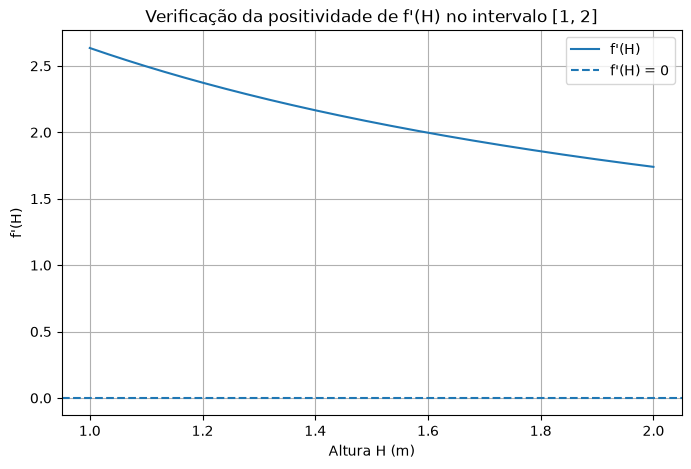

In [6]:
H_derivada = np.linspace(1, 2, 400)

df_valores = [
    derivada_f(H)
    for H in H_derivada
]

plt.figure(figsize=(8, 5))

plt.plot(
    H_derivada,
    df_valores,
    label="f'(H)"
)

plt.axhline(
    0,
    linestyle="--",
    label="f'(H) = 0"
)

plt.xlabel("Altura H (m)")
plt.ylabel("f'(H)")

plt.title(
    "Verificação da positividade de f'(H) no intervalo [1, 2]"
)

plt.grid(True)
plt.legend()

plt.show()

<a id="criterios"></a>

## 5. Definição dos critérios de parada

Para comparar os métodos de Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante sob um mesmo nível de exigência numérica, serão adotados parâmetros comuns de parada:

$$
e_H=10^{-6}\,\text{m},
\qquad
e_F=10^{-6}\,\text{m/s},
\qquad
N_{\max}=100.
$$

O critério $e_H$ está associado à variação entre aproximações consecutivas, enquanto $e_F$ está associado ao resíduo da equação. Sikorski e Woźniakowski (1986), ao estudarem critérios de erro para equações escalares não lineares, distinguem explicitamente critérios relacionados à raiz e critérios residuais. Igarashi (1985a; 1985b), em estudos voltados aos problemas práticos e às regras de parada na determinação de raízes, também destaca que a condição de término deve ser analisada de acordo com a informação de erro que se pretende controlar.

A adoção dos mesmos parâmetros para todos os métodos tem finalidade comparativa: evita que diferenças no número de iterações sejam produzidas simplesmente por níveis distintos de tolerância ou por limites de execução diferentes. Em estudo comparativo recente, Sharma e Chouhan (2026) avaliam métodos iterativos de determinação de raízes sob um mesmo protocolo experimental, utilizando critérios de tolerância comuns aos métodos comparados e um limite máximo de 100 iterações. A adoção de condições comuns de execução permite que as diferenças observadas no desempenho sejam analisadas sem introduzir limites de iteração distintos entre os algoritmos.

Neste trabalho, a convergência será considerada quando os critérios de parada aplicáveis a cada método forem satisfeitos simultaneamente. Para os cinco métodos são considerados os critérios associados ao erro entre aproximações e ao resíduo; para a Bisseção, também é monitorado o critério adicional associado ao intervalo de confinamento da raiz. O valor $N_{\max}$ funciona apenas como limite de segurança: atingir 100 iterações não significa convergência. As justificativas específicas das tolerâncias e do limite máximo são apresentadas nas seções seguintes.


<a id="tolerancias"></a>

## 6. Escolha das tolerâncias

A definição das tolerâncias determina o nível de exigência utilizado para encerrar um processo iterativo. Neste trabalho, são acompanhadas duas grandezas diferentes. A primeira é a diferença entre aproximações consecutivas da altura:

$$
|H_n-H_{n-1}|<e_H,
$$

com

$$
\boxed{e_H=10^{-6}\,\text{m}}.
$$

Esse critério permite verificar se a sequência de aproximações está se estabilizando. Entretanto, uma pequena diferença entre duas aproximações sucessivas não implica, isoladamente, que a equação original esteja sendo satisfeita com resíduo pequeno.

Por isso, também será utilizado o critério residual:

$$
|f(H_n)|<e_F,
$$

com

$$
\boxed{e_F=10^{-6}\,\text{m/s}}.
$$

Sikorski e Woźniakowski (1986) distinguem formalmente o critério relacionado à raiz do critério residual na resolução de equações não lineares. Essa distinção sustenta a utilização de medidas diferentes para avaliar a aproximação: uma associada ao comportamento das iteradas e outra ao valor assumido pela própria função. Igarashi (1985a; 1985b) também discute a importância dos critérios práticos de término e da avaliação da precisão em algoritmos de determinação de raízes.

Assim, neste experimento, os métodos serão submetidos, sempre que aplicável, às condições simultâneas:

$$
\boxed{
|H_n-H_{n-1}|<10^{-6}\,\text{m}
\quad\text{e}\quad
|f(H_n)|<10^{-6}\,\text{m/s}
}
$$

A escolha do valor numérico $10^{-6}$ é uma decisão metodológica do experimento, e não uma constante universal indicada pela literatura. O ponto importante para a análise comparativa é que o mesmo nível de tolerância seja aplicado aos métodos, evitando favorecer um algoritmo por submetê-lo a uma exigência numérica menor. Estudos comparativos de métodos de raízes utilizam parâmetros de parada comuns para tornar a comparação de desempenho coerente. Sharma e Chouhan (2026), por exemplo, submetem os métodos comparados no estudo às mesmas tolerâncias e ao mesmo limite máximo de iterações, estabelecendo um protocolo experimental comum para a avaliação do desempenho.

Embora $e_H$ e $e_F$ possuam o mesmo valor numérico, eles não representam a mesma grandeza: $e_H$ é expresso em metros e controla a variação da altura, enquanto $e_F$ é expresso em metros por segundo e controla o resíduo associado à velocidade. Também não se afirma que $10^{-6}$ garanta automaticamente seis casas decimais corretas na raiz. Neste trabalho, esse valor deve ser interpretado como o limiar adotado para os critérios de convergência.


<a id="criterio"></a>

## 7. Critério adicional para o Método da Bisseção 

O Método da Bisseção possui uma característica que permite estabelecer diretamente um limite para o erro da aproximação. O método parte de um intervalo $[a,b]$ que contém uma raiz e, a cada iteração, divide esse intervalo ao meio, preservando o subintervalo no qual ocorre a mudança de sinal. Brent (1971), em seu trabalho sobre um algoritmo com convergência garantida para determinação de zeros de funções, utiliza a Bisseção como procedimento seguro para preservar o confinamento da raiz quando etapas de interpolação não são adequadas.

Se, na iteração $n$, a raiz $H^*$ está confinada no intervalo $[a_n,b_n]$ e $H_n$ é escolhido como seu ponto médio, então:

$$
H_n=\frac{a_n+b_n}{2}
$$

Como a raiz permanece dentro do intervalo, a maior distância possível entre o ponto médio e qualquer ponto pertencente a esse intervalo corresponde à metade de seu comprimento. Portanto:

$$
\boxed{
|H^*-H_n|
\leq
\frac{b_n-a_n}{2}
}
$$

Essa propriedade fornece à Bisseção uma estimativa direta do limite superior para o erro da aproximação, independentemente do valor exato de $H^*$.

Por esse motivo, além dos critérios gerais utilizados para comparar os cinco métodos, será monitorada, especificamente para a Bisseção, a condição:

$$
\boxed{
\frac{b_n-a_n}{2}<10^{-6}\,\text{m}
}
$$

O valor $10^{-6}\,\text{m}$ corresponde à tolerância para a variável $H$ definida anteriormente. Esse critério adicional permite relacionar diretamente o comprimento do intervalo de confinamento ao limite teórico do erro do ponto médio.

<a id="limite"></a>

## 8. Limite máximo de iterações

Além das tolerâncias, os algoritmos precisam de uma condição de segurança que encerre a execução caso os critérios de convergência não sejam alcançados. Por isso, será adotado:

$$
\boxed{N_{\max}=100}
$$

A escolha de 100 iterações encontra precedente direto na literatura científica comparativa. Sharma e Chouhan (2026), em estudo publicado no periódico *Discover Computing* sobre o desempenho computacional de métodos clássicos e híbridos de determinação de raízes, comparam Newton, Secante, Weerakoon–Fernando e um método híbrido Newton–Secante. No protocolo experimental adotado pelos autores, as iterações são encerradas quando um dos critérios de tolerância definidos é satisfeito ou quando se atinge o limite máximo de 100 iterações. Os métodos comparados são, portanto, submetidos ao mesmo limite máximo de execução.

Esse estudo não estabelece que 100 seja um número universal ou matematicamente obrigatório para todos os métodos de determinação de raízes. Ele fornece, porém, um precedente científico para a utilização de $N_{\max}=100$ como salvaguarda computacional em uma análise comparativa. Com base nesse precedente, este trabalho adota o mesmo limite para Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante, preservando uma condição uniforme de execução entre os cinco algoritmos.

Atingir $N_{\max}$ não significa que o método convergiu. Neste trabalho, a convergência é determinada pelos critérios de tolerância definidos anteriormente. Se eles não forem satisfeitos antes do limite de 100 iterações, o método será registrado como não convergente nas condições estabelecidas para o experimento.




In [7]:
tolerancia_H = 1e-6
tolerancia_f = 1e-6
max_iter = 100

print(f"Tolerância das iteradas = {tolerancia_H:.0e} m")
print(f"Tolerância residual     = {tolerancia_f:.0e} m/s")
print(f"Máximo de iterações     = {max_iter}")

Tolerância das iteradas = 1e-06 m
Tolerância residual     = 1e-06 m/s
Máximo de iterações     = 100


<a id="dados-comparacao"></a>

## 9. Dados utilizados na análise comparativa

Antes da aplicação dos métodos numéricos, é necessário definir quais informações serão coletadas durante as execuções e quais delas serão utilizadas posteriormente na análise comparativa. Essa definição permite que os diferentes métodos sejam avaliados de maneira organizada, utilizando indicadores comuns sempre que possível.

Neste trabalho, os métodos do Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante serão executados considerando as mesmas tolerâncias para o erro entre aproximações consecutivas e para o resíduo da função, além do mesmo limite máximo de execução:

$$
e_H=10^{-6}\,\text{m},
\qquad
e_F=10^{-6}\,\text{m/s},
\qquad
N_{\max}=100.
$$

Esses valores estabelecem condições comuns para a realização do experimento numérico. O limite $N_{\max}=100$ representa apenas o número máximo de iterações permitido e não constitui, por si só, um critério de convergência.

Para cada método, serão coletadas as seguintes informações:

| Dado coletado | Descrição | Finalidade na análise |
|---|---|---|
| Raiz aproximada | Valor final obtido para $H$ | Comparar as soluções produzidas pelos métodos |
| Convergência | Indica se os critérios de parada foram satisfeitos | Verificar se o método convergiu nas condições estabelecidas |
| Número de iterações | Quantidade de iterações realizadas | Comparar o comportamento iterativo dos métodos |
| Erro final | Diferença absoluta entre aproximações consecutivas | Avaliar a estabilização das aproximações |
| Resíduo final |  Valor de $\lvert f(H)\rvert$ na aproximação obtida  | Avaliar o quanto a solução satisfaz a equação original |
| Histórico das iterações | Valores registrados durante cada iteração | Acompanhar e representar graficamente o processo de convergência |

Assim, para os métodos em geral, o erro entre aproximações consecutivas é calculado por:

$$
e_H^{(n)}
=
|H_n-H_{n-1}|,
$$

enquanto o resíduo é calculado por:

$$
e_F^{(n)}
=
|f(H_n)|.
$$

Essas duas medidas representam aspectos diferentes do processo iterativo. O erro entre aproximações consecutivas indica o quanto a solução está se modificando de uma iteração para a seguinte, enquanto o resíduo indica o quanto a aproximação atual satisfaz a equação original $f(H)=0$.

Além dos dados comuns, o Método da Bisseção também registra o erro associado ao intervalo de confinamento da raiz:

$$
e_{\text{intervalo}}^{(n)}
=
\frac{b_n-a_n}{2}.
$$

Esse valor é específico da estrutura da Bisseção e será utilizado como informação adicional para acompanhar a redução do intervalo durante o processo iterativo.

O histórico armazenado por cada método permite acompanhar a evolução das aproximações ao longo das iterações. A partir desses registros, serão construídas tabelas e representações gráficas para auxiliar na interpretação do comportamento dos algoritmos.

Portanto, a análise comparativa será realizada principalmente a partir de cinco informações finais comuns:

$$
\boxed{
\text{raiz aproximada, convergência, iterações, erro final e resíduo final}
}
$$

O histórico das iterações será utilizado para analisar a evolução do processo de convergência, enquanto o erro associado ao intervalo será considerado adicionalmente no caso específico da Bisseção.

É importante destacar que o número de iterações não será interpretado isoladamente como uma medida universal de eficiência. Os resultados serão analisados no contexto da função estudada, das condições iniciais, dos critérios de parada adotados e das características próprias de cada método.

<a id="aplicacao"></a>

# 3. APLICAÇÃO DOS MÉTODOS NUMÉRICOS

Nesta seção, os algoritmos são apenas **chamados**. Suas implementações permanecem em `src/metodos_numericos/`.

Para manter a comparação coerente, todos os métodos utilizam:

$$
\varepsilon_H=10^{-6},
\qquad
\varepsilon_f=10^{-6},
\qquad
N_{\max}=100
$$

<a id="ponto-fixo"></a>

## 3.1 Método do Ponto Fixo

Para aplicar o Método do Ponto Fixo, a equação $f(H)=0$ deve ser reescrita na forma:

$$
H=\phi(H)
$$

A função de iteração $\phi(H)$ utilizada neste trabalho é obtida a partir da própria equação do problema. Partindo de:

$$
f(H)=
\sqrt{19{,}62H}\,
\tanh\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)-5=0
$$

isolando o termo correspondente à velocidade, obtém-se:

$$
\sqrt{19{,}62H}\,
\tanh\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)=5
$$

Dividindo os dois membros pelo termo hiperbólico:

$$
\sqrt{19{,}62H}
=
\frac{5}{
\tanh\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
$$

Elevando os dois membros ao quadrado:

$$
19{,}62H
=
\frac{25}{
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
$$

Por fim, dividindo os dois membros por $19{,}62$, a variável $H$ fica isolada:

$$
H=
\frac{25}{
19{,}62
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
$$

Dessa forma, comparando a expressão obtida com $H=\phi(H)$, define-se a função de iteração:

$$
\boxed{
\phi(H)=
\frac{25}{
19{,}62
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H}}{8}
\right)
}
}
$$

Assim, o processo iterativo do Método do Ponto Fixo é dado por:

$$
H_{n+1}=\phi(H_n)
$$

ou, explicitamente:

$$
H_{n+1}
=
\frac{25}{
19{,}62
\tanh^2\left(
\frac{2{,}5\sqrt{19{,}62H_n}}{8}
\right)
}
$$

Como aproximação inicial, será utilizado o ponto médio do intervalo $[1,2]$, previamente estabelecido pela análise da mudança de sinal da função:

$$
H_0=\frac{1+2}{2}=1{,}5
$$

Portanto:

$$
\boxed{H_0=1{,}5}
$$

In [8]:
def phi(H):
    argumento = (2.5 * math.sqrt(19.62 * H)) / 8

    return 25 / (
        19.62
        * math.tanh(argumento) ** 2
    )

resultado_pf = ponto_fixo(
    phi=phi,
    f=f,
    x0=1.5,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_pf

{'raiz': 1.465894515445561,
 'convergiu': True,
 'iteracoes': 9,
 'erro': 3.837320974309222e-07,
 'residuo': 1.5382663942631325e-07,
 'historico': [{'iteracao': 1,
   'x_anterior': 1.5,
   'x_atual': 1.458097784293705,
   'erro': 0.04190221570629493,
   'residuo': 0.016449093385046076},
  {'iteracao': 2,
   'x_anterior': 1.458097784293705,
   'x_atual': 1.4677390900328726,
   'erro': 0.00964130573916755,
   'residuo': 0.0038836150604311115},
  {'iteracao': 3,
   'x_anterior': 1.4677390900328726,
   'x_atual': 1.4654616902854805,
   'erro': 0.0022773997473921614,
   'residuo': 0.0009119009108884413},
  {'iteracao': 4,
   'x_anterior': 1.4654616902854805,
   'x_atual': 1.4659963788960406,
   'erro': 0.0005346886105601634,
   'residuo': 0.000214397983326009},
  {'iteracao': 5,
   'x_anterior': 1.4659963788960406,
   'x_atual': 1.4658706643151045,
   'erro': 0.00012571458093613153,
   'residuo': 5.039202679490984e-05},
  {'iteracao': 6,
   'x_anterior': 1.4658706643151045,
   'x_atual': 1.

In [9]:
tabela_pf = pd.DataFrame(resultado_pf["historico"])
tabela_pf

,iteracao,x_anterior,x_atual,erro,residuo
0,1,1.500000,1.458098,4.190222e-02,1.644909e-02
1,2,1.458098,1.467739,9.641306e-03,3.883615e-03
2,3,1.467739,1.465462,2.277400e-03,9.119009e-04
3,4,1.465462,1.465996,5.346886e-04,2.143980e-04
4,5,1.465996,1.465871,1.257146e-04,5.039203e-05
5,6,1.465871,1.465900,2.954772e-05,1.184497e-05
6,7,1.465900,1.465893,6.945393e-06,2.784190e-06
7,8,1.465893,1.465895,1.632531e-06,6.544333e-07
8,9,1.465895,1.465895,3.837321e-07,1.538266e-07


<a id="bissecao"></a>

## 3.2 Método da Bisseção

O Método da Bisseção é um método de confinamento para determinação de raízes de equações não lineares. Sua aplicação parte de um intervalo $[a,b]$ no qual uma função contínua apresenta valores com sinais opostos nos extremos.

Para o problema deste trabalho, foi verificado anteriormente que:

$$
f(1)\approx-1{,}093721<0
$$

e

$$
f(2)\approx1{,}019273>0
$$

Portanto:

$$
f(1)\cdot f(2)<0
$$

Como $f(H)$ é contínua no intervalo considerado, a mudança de sinal garante a existência de pelo menos uma raiz entre os extremos. Além disso, a análise da derivada realizada anteriormente mostrou que $f(H)$ é estritamente crescente para $H>0$, permitindo concluir que a raiz existente nesse intervalo é única.

Dessa forma, será utilizado como intervalo inicial:

$$
\boxed{[a,b]=[1,2]}
$$

A escolha específica dos valores $1$ e $2$ decorre da análise da função deste problema e não de uma exigência do Método da Bisseção.

Em cada iteração, o método calcula o ponto médio do intervalo corrente:

$$
H_n=\frac{a_n+b_n}{2}
$$

e avalia $f(H_n)$. A partir do sinal obtido, é selecionado o subintervalo no qual a mudança de sinal permanece. Dessa forma, a raiz continua confinada entre os extremos do novo intervalo.

Como o comprimento do intervalo é reduzido pela metade a cada iteração, a Bisseção também permite estabelecer um limite para o erro associado ao ponto médio:

$$
|H^*-H_n|
\leq
\frac{b_n-a_n}{2}
$$

Esse limite decorre diretamente da redução sucessiva do intervalo realizada pelo Método da Bisseção e permite acompanhar, adicionalmente, o erro máximo associado ao ponto médio utilizado como aproximação.


In [10]:
resultado_bis = bissecao(
    f=f,
    a=1.0,
    b=2.0,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_bis

{'raiz': 1.4658942222595215,
 'convergiu': True,
 'iteracoes': 21,
 'erro': 4.76837158203125e-07,
 'residuo': 7.7136831588831e-07,
 'erro_intervalo': 4.76837158203125e-07,
 'historico': [{'iteracao': 1,
   'a': 1.0,
   'b': 2.0,
   'x_atual': 1.5,
   'f_x': 0.0713351042635546,
   'erro': 0.5,
   'erro_intervalo': 0.5,
   'residuo': 0.0713351042635546},
  {'iteracao': 2,
   'a': 1.0,
   'b': 1.5,
   'x_atual': 1.25,
   'f_x': -0.47666313270744975,
   'erro': 0.25,
   'erro_intervalo': 0.25,
   'residuo': 0.47666313270744975},
  {'iteracao': 3,
   'a': 1.25,
   'b': 1.5,
   'x_atual': 1.375,
   'f_x': -0.19516910613045457,
   'erro': 0.125,
   'erro_intervalo': 0.125,
   'residuo': 0.19516910613045457},
  {'iteracao': 4,
   'a': 1.375,
   'b': 1.5,
   'x_atual': 1.4375,
   'f_x': -0.06016290703391114,
   'erro': 0.0625,
   'erro_intervalo': 0.0625,
   'residuo': 0.06016290703391114},
  {'iteracao': 5,
   'a': 1.4375,
   'b': 1.5,
   'x_atual': 1.46875,
   'f_x': 0.006010838389600259,
   

In [11]:
tabela_bis = pd.DataFrame(resultado_bis["historico"])
tabela_bis

,iteracao,a,b,x_atual,f_x,erro,erro_intervalo,residuo
0,1,1.000000,2.000000,1.500000,7.133510e-02,5.000000e-01,5.000000e-01,7.133510e-02
1,2,1.000000,1.500000,1.250000,-4.766631e-01,2.500000e-01,2.500000e-01,4.766631e-01
2,3,1.250000,1.500000,1.375000,-1.951691e-01,1.250000e-01,1.250000e-01,1.951691e-01
3,4,1.375000,1.500000,1.437500,-6.016291e-02,6.250000e-02,6.250000e-02,6.016291e-02
4,5,1.437500,1.500000,1.468750,6.010838e-03,3.125000e-02,3.125000e-02,6.010838e-03
5,6,1.437500,1.468750,1.453125,-2.696817e-02,1.562500e-02,1.562500e-02,2.696817e-02
6,7,1.453125,1.468750,1.460938,-1.045192e-02,7.812500e-03,7.812500e-03,1.045192e-02
7,8,1.460938,1.468750,1.464844,-2.213877e-03,3.906250e-03,3.906250e-03,2.213877e-03
8,9,1.464844,1.468750,1.466797,1.900143e-03,1.953125e-03,1.953125e-03,1.900143e-03
9,10,1.464844,1.466797,1.465820,-1.564509e-04,9.765625e-04,9.765625e-04,1.564509e-04


<a id="falsa-posicao"></a>

## 3.3 Método da Falsa Posição

O Método da Falsa Posição é um método de determinação de raízes que utiliza um intervalo inicial $[a,b]$ no qual a função apresenta sinais opostos nos extremos. Assim como ocorre na Bisseção, essa condição permite manter a raiz confinada em um intervalo durante o processo iterativo.

Para o problema deste trabalho, foi verificado anteriormente que:

$$
f(1)\approx-1{,}093721<0
$$

e

$$
f(2)\approx1{,}019273>0
$$

Portanto:

$$
f(1)\cdot f(2)<0
$$

Como $f(H)$ é contínua no intervalo considerado, a mudança de sinal garante a existência de pelo menos uma raiz entre os extremos. Dessa forma, será utilizado como intervalo inicial:

$$
\boxed{[a,b]=[1,2]}
$$

A escolha específica dos valores $1$ e $2$ decorre da análise da função deste problema e não de uma exigência do Método da Falsa Posição.

Diferentemente da Bisseção, que utiliza o ponto médio do intervalo como nova aproximação, a Falsa Posição utiliza uma interpolação linear entre os pontos $(a_n,f(a_n))$ e $(b_n,f(b_n))$. A interseção da reta determinada por esses dois pontos com o eixo horizontal fornece a nova aproximação da raiz.

Essa aproximação pode ser calculada por:

$$
H_n=
\frac{
a_nf(b_n)-b_nf(a_n)
}{
f(b_n)-f(a_n)
}
$$

ou, de forma equivalente:

$$
H_n=
a_n-
f(a_n)
\frac{
b_n-a_n
}{
f(b_n)-f(a_n)
}
$$

Após o cálculo de $H_n$, o sinal de $f(H_n)$ é utilizado para determinar qual extremo do intervalo deve ser substituído. O novo intervalo é escolhido de forma que a mudança de sinal seja preservada:

$$
f(a_n)\cdot f(b_n)<0
$$

Dessa maneira, a raiz permanece confinada durante as iterações.

Portanto, embora Bisseção e Falsa Posição utilizem o mesmo intervalo inicial neste trabalho, os métodos diferem na forma de determinar a nova aproximação: a Bisseção utiliza o ponto médio do intervalo, enquanto a Falsa Posição utiliza a interseção de uma reta secante com o eixo horizontal.

In [12]:
resultado_fp = falsa_posicao(
    f=f,
    a=1.0,
    b=2.0,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_fp

{'raiz': 1.4658946489984679,
 'convergiu': True,
 'iteracoes': 7,
 'erro': 5.283878938833197e-07,
 'residuo': 1.2747761068965247e-07,
 'historico': [{'iteracao': 1,
   'a': 1.0,
   'b': 2.0,
   'x_atual': 1.5176165605224028,
   'f_x': 0.10779579481488533,
   'erro': 0.5176165605224028,
   'residuo': 0.10779579481488533},
  {'iteracao': 2,
   'a': 1.0,
   'b': 1.5176165605224028,
   'x_atual': 1.4711778342341593,
   'f_x': 0.011116018090119084,
   'erro': 0.046438726288243526,
   'residuo': 0.011116018090119084},
  {'iteracao': 3,
   'a': 1.0,
   'b': 1.4711778342341593,
   'x_atual': 1.4664372042693197,
   'f_x': 0.0011427904098342268,
   'erro': 0.004740629964839593,
   'residuo': 0.0011427904098342268},
  {'iteracao': 4,
   'a': 1.0,
   'b': 1.4664372042693197,
   'x_atual': 1.4659503490195545,
   'f_x': 0.00011744781035449847,
   'erro': 0.00048685524976521677,
   'residuo': 0.00011744781035449847},
  {'iteracao': 5,
   'a': 1.0,
   'b': 1.4659503490195545,
   'x_atual': 1.465900318

In [13]:
tabela_fp = pd.DataFrame(resultado_fp["historico"])
tabela_fp

,iteracao,a,b,x_atual,f_x,erro,residuo
0,1,1.0,2.000000,1.517617,1.077958e-01,5.176166e-01,1.077958e-01
1,2,1.0,1.517617,1.471178,1.111602e-02,4.643873e-02,1.111602e-02
2,3,1.0,1.471178,1.466437,1.142790e-03,4.740630e-03,1.142790e-03
3,4,1.0,1.466437,1.465950,1.174478e-04,4.868552e-04,1.174478e-04
4,5,1.0,1.465950,1.465900,1.207005e-05,5.003012e-05,1.207005e-05
5,6,1.0,1.465900,1.465895,1.240428e-06,5.141511e-06,1.240428e-06
6,7,1.0,1.465895,1.465895,1.274776e-07,5.283879e-07,1.274776e-07


<a id="newton"></a>

## 3.4 Método de Newton-Raphson

O Método de Newton-Raphson é um método iterativo para determinação de raízes de equações não lineares. A partir de uma aproximação inicial $H_0$, as aproximações seguintes são calculadas por:

$$
H_{n+1}
=
H_n-
\frac{f(H_n)}{f'(H_n)}
$$

Diferentemente dos métodos de confinamento, como a Bisseção, o Método de Newton-Raphson necessita de uma aproximação inicial para iniciar o processo iterativo. A escolha desse valor pode influenciar o comportamento e a convergência do método.

Neste trabalho, já foi estabelecido anteriormente que a raiz procurada está no intervalo:

$$
[1,2]
$$

Como não se deseja utilizar o valor previamente conhecido da solução para favorecer a escolha da aproximação inicial, será adotado o ponto médio desse intervalo como critério objetivo para definir $H_0$:

$$
H_0=\frac{a+b}{2}
$$

Substituindo $a=1$ e $b=2$:

$$
H_0=\frac{1+2}{2}=1{,}5
$$

Portanto:

$$
\boxed{H_0=1{,}5}
$$

A escolha de $H_0=1{,}5$ é, portanto, uma decisão metodológica deste trabalho baseada no intervalo previamente identificado como contendo a raiz, e não no conhecimento antecipado do valor da solução.

In [14]:
resultado_newton = newton_raphson(
    f=f,
    df=derivada_f,
    x0=1.5,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_newton

{'raiz': 1.465894588476788,
 'convergiu': True,
 'iteracoes': 3,
 'erro': 1.1804262234349494e-08,
 'residuo': 0.0,
 'historico': [{'iteracao': 1,
   'x_anterior': 1.5,
   'x_atual': 1.4656558299722453,
   'erro': 0.034344170027754695,
   'residuo': 0.0005029250498100879},
  {'iteracao': 2,
   'x_anterior': 1.4656558299722453,
   'x_atual': 1.4658945766725258,
   'erro': 0.00023874670028045664,
   'residuo': 2.486347305818981e-08},
  {'iteracao': 3,
   'x_anterior': 1.4658945766725258,
   'x_atual': 1.465894588476788,
   'erro': 1.1804262234349494e-08,
   'residuo': 0.0}]}

In [15]:
tabela_newton = pd.DataFrame(resultado_newton["historico"])
tabela_newton

,iteracao,x_anterior,x_atual,erro,residuo
0,1,1.500000,1.465656,3.434417e-02,5.029250e-04
1,2,1.465656,1.465895,2.387467e-04,2.486347e-08
2,3,1.465895,1.465895,1.180426e-08,0.000000e+00


<a id="secante"></a>

## 3.5 Método da Secante

O Método da Secante é um método iterativo para determinação de raízes de equações não lineares que, diferentemente do Método de Newton-Raphson, não necessita do cálculo analítico da derivada. Em seu lugar, utiliza a inclinação da reta secante determinada por duas aproximações consecutivas.

O processo iterativo é dado por:

$$
H_{n+1}
=
H_n-
f(H_n)
\frac{H_n-H_{n-1}}
{f(H_n)-f(H_{n-1})}
$$

Como o cálculo de uma nova aproximação depende de dois valores anteriores, o Método da Secante necessita de duas aproximações iniciais, $H_0$ e $H_1$.

Neste trabalho, já foi estabelecido anteriormente que a raiz procurada está no intervalo $[1,2]$, pois:

$$
f(1)\approx-1{,}093721<0
$$

e

$$
f(2)\approx1{,}019273>0
$$

Portanto:

$$
f(1)\cdot f(2)<0
$$

Como critério objetivo para a escolha das duas aproximações iniciais, serão utilizados os próprios extremos do intervalo previamente identificado como contendo a raiz:

$$
\boxed{H_0=1}
$$

e

$$
\boxed{H_1=2}
$$

Essa escolha é uma decisão metodológica deste trabalho e evita utilizar conhecimento antecipado do valor da solução para selecionar aproximações artificialmente próximas da raiz.

É importante observar que, embora $H_0$ e $H_1$ tenham sido escolhidos a partir do intervalo $[1,2]$, o Método da Secante não é um método de confinamento como a Bisseção. Assim, suas aproximações posteriores não são obrigadas a permanecer dentro desse intervalo.

In [16]:
resultado_sec = secante(
    f=f,
    x0=1.0,
    x1=2.0,
    tolerancia_x=tolerancia_H,
    tolerancia_f=tolerancia_f,
    max_iter=max_iter,
)

resultado_sec

{'raiz': 1.4658945884760528,
 'convergiu': True,
 'iteracoes': 5,
 'erro': 6.260106855116021e-08,
 'residuo': 1.5489831639570184e-12,
 'historico': [{'iteracao': 1,
   'x_anterior': 2.0,
   'x_atual': 1.5176165605224028,
   'erro': 0.4823834394775972,
   'residuo': 0.10779579481488533},
  {'iteracao': 2,
   'x_anterior': 1.5176165605224028,
   'x_atual': 1.4605675246336387,
   'erro': 0.05704903588876409,
   'residuo': 0.011232863302264029},
  {'iteracao': 3,
   'x_anterior': 1.4605675246336387,
   'x_atual': 1.4659513038999203,
   'erro': 0.005383779266281641,
   'residuo': 0.00011945904061771984},
  {'iteracao': 4,
   'x_anterior': 1.4659513038999203,
   'x_atual': 1.4658946510771214,
   'erro': 5.665282279898598e-05,
   'residuo': 1.3185590574948947e-07},
  {'iteracao': 5,
   'x_anterior': 1.4658946510771214,
   'x_atual': 1.4658945884760528,
   'erro': 6.260106855116021e-08,
   'residuo': 1.5489831639570184e-12}]}

In [17]:
tabela_sec = pd.DataFrame(resultado_sec["historico"])
tabela_sec

,iteracao,x_anterior,x_atual,erro,residuo
0,1,2.000000,1.517617,4.823834e-01,1.077958e-01
1,2,1.517617,1.460568,5.704904e-02,1.123286e-02
2,3,1.460568,1.465951,5.383779e-03,1.194590e-04
3,4,1.465951,1.465895,5.665282e-05,1.318559e-07
4,5,1.465895,1.465895,6.260107e-08,1.548983e-12


<a id="tabela-comparativa"></a>
# 4. TABELA COMPARATIVA DOS RESULTADOS

Para comparar os métodos sob os mesmos critérios, será construída uma tabela com:

- aproximação final;
- número de iterações;
- erro entre as duas últimas aproximações;
- resíduo final;
- indicação de convergência.

In [18]:
resultados = {
    "Ponto Fixo": resultado_pf,
    "Bisseção": resultado_bis,
    "Falsa Posição": resultado_fp,
    "Newton-Raphson": resultado_newton,
    "Secante": resultado_sec,
}

dados_comparacao = []

for metodo, resultado in resultados.items():
    dados_comparacao.append(
        {
            "Método": metodo,
            "Raiz aproximada (m)": resultado["raiz"],
            "Iterações": resultado["iteracoes"],
            "Erro final": resultado["erro"],
            "Resíduo final": resultado["residuo"],
            "Convergiu": resultado["convergiu"],
        }
    )

tabela_comparativa = pd.DataFrame(dados_comparacao)

tabela_comparativa

,Método,Raiz aproximada (m),Iterações,Erro final,Resíduo final,Convergiu
0,Ponto Fixo,1.465895,9,3.837321e-07,1.538266e-07,True
1,Bisseção,1.465894,21,4.768372e-07,7.713683e-07,True
2,Falsa Posição,1.465895,7,5.283879e-07,1.274776e-07,True
3,Newton-Raphson,1.465895,3,1.180426e-08,0.000000e+00,True
4,Secante,1.465895,5,6.260107e-08,1.548983e-12,True


<a id="graficos"></a>
# 5. GRÁFICOS COMPARATIVOS

Os gráficos abaixo permitem comparar visualmente o comportamento dos métodos em termos de número de iterações, erro final e resíduo final.

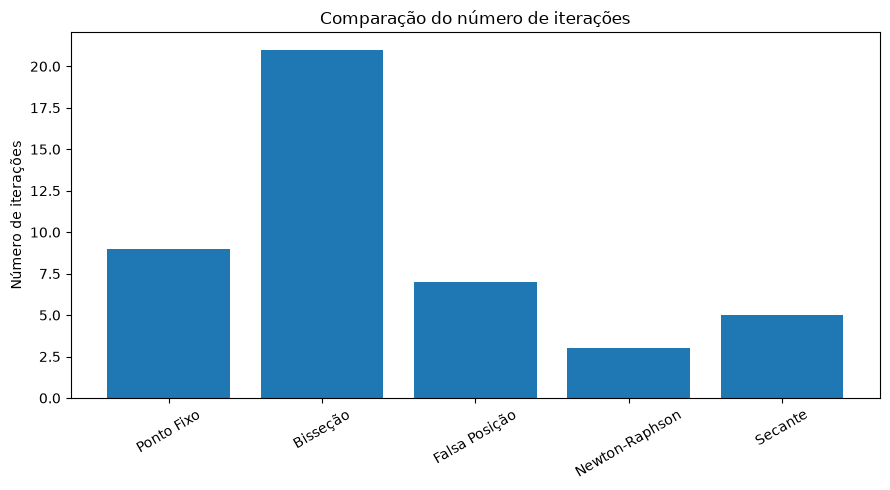

In [19]:
plt.figure(figsize=(9, 5))
plt.bar(
    tabela_comparativa["Método"],
    tabela_comparativa["Iterações"]
)
plt.ylabel("Número de iterações")
plt.title("Comparação do número de iterações")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

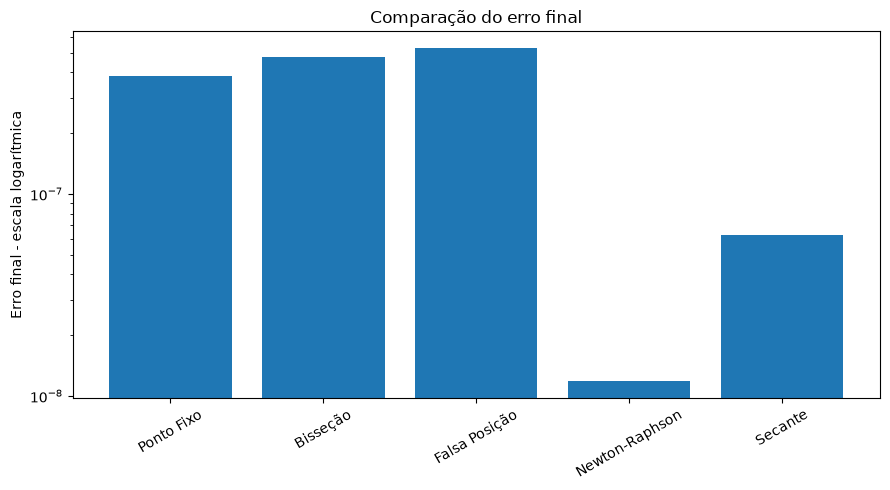

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(
    tabela_comparativa["Método"],
    tabela_comparativa["Erro final"]
)
plt.yscale("log")
plt.ylabel("Erro final - escala logarítmica")
plt.title("Comparação do erro final")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

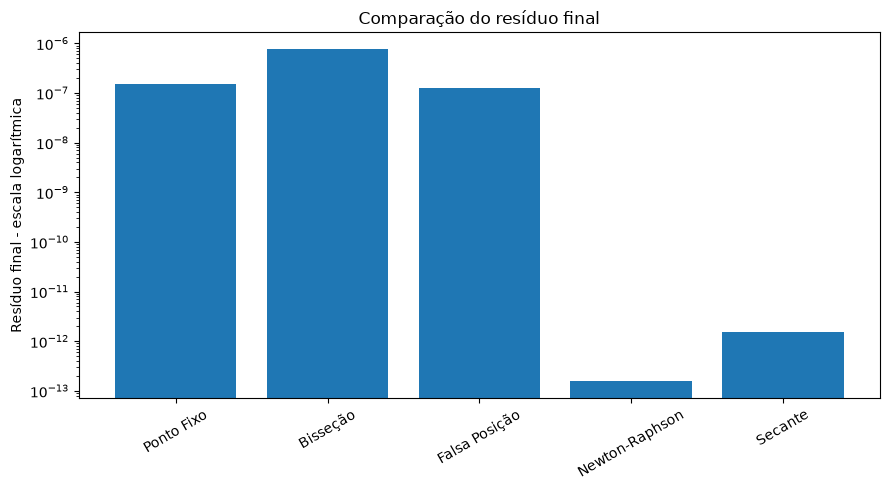

In [22]:
residuos_grafico = tabela_comparativa["Resíduo final"].copy()

menor_positivo = residuos_grafico[residuos_grafico > 0].min()

residuos_grafico = residuos_grafico.replace(
    0,
    menor_positivo / 10
)

plt.figure(figsize=(9, 5))

plt.bar(
    tabela_comparativa["Método"],
    residuos_grafico
)

plt.yscale("log")

plt.ylabel("Resíduo final - escala logarítmica")
plt.title("Comparação do resíduo final")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Convergência das aproximações

O gráfico seguinte utiliza os históricos retornados pelos métodos. Como os nomes das colunas de aproximação podem variar entre os algoritmos, a célula procura automaticamente uma coluna adequada para cada histórico.

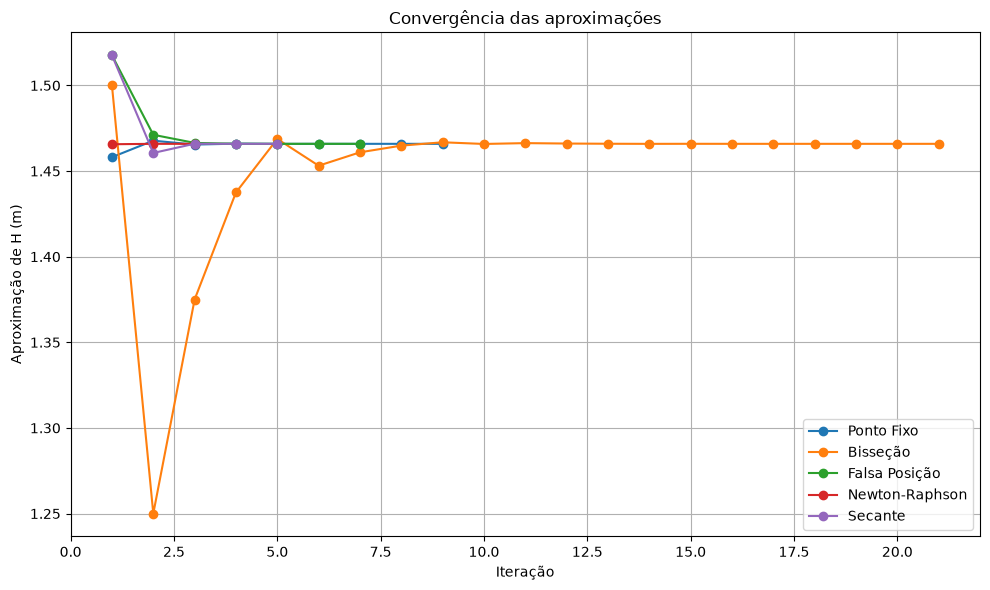

In [23]:
def obter_aproximacoes(historico):
    df = pd.DataFrame(historico)

    candidatos = [
        "x_atual",
        "x_n_mais_1",
        "x",
        "c",
        "raiz",
        "aproximacao",
    ]

    for coluna in candidatos:
        if coluna in df.columns:
            return df[coluna].tolist()

    numericas = [
        coluna
        for coluna in df.columns
        if coluna != "iteracao"
        and pd.api.types.is_numeric_dtype(df[coluna])
    ]

    if numericas:
        return df[numericas[-1]].tolist()

    return []

plt.figure(figsize=(10, 6))

for metodo, resultado in resultados.items():
    aproximacoes = obter_aproximacoes(
        resultado["historico"]
    )

    if aproximacoes:
        iteracoes = range(1, len(aproximacoes) + 1)

        plt.plot(
            iteracoes,
            aproximacoes,
            marker="o",
            label=metodo,
        )

plt.xlabel("Iteração")
plt.ylabel("Aproximação de H (m)")
plt.title("Convergência das aproximações")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<a id="analise"></a>

# 6. ANÁLISE COMPARATIVA

Os cinco métodos convergiram para valores praticamente coincidentes da altura inicial da coluna de água. Considerando seis casas decimais, todos conduziram ao mesmo resultado:

$$
\boxed{H \approx 1{,}465895\ \text{m}}
$$

Esse resultado indica consistência entre as diferentes estratégias numéricas empregadas para resolver a equação não linear do problema. A comparação, entretanto, não deve considerar somente a proximidade das raízes obtidas, mas também o número de iterações, o erro entre aproximações consecutivas, o resíduo final e as características próprias de cada método.

Sob as condições estabelecidas neste experimento, com $e_H=10^{-6}\,\text{m}$, $e_F=10^{-6}\,\text{m/s}$ e 
$N_{\max}=100$, todos os métodos foram registrados como convergentes antes de atingir o limite máximo de execução. Para a Bisseção, também foi monitorado o critério adicional associado à metade do comprimento do intervalo de confinamento.

| Método | Raiz aproximada (m) | Iterações | Erro final | Resíduo final |
|---|---:|---:|---:|---:|
| Ponto Fixo | 1,465894515 | 9 | $3{,}8373\times10^{-7}$ | $1{,}5383\times10^{-7}$ |
| Bisseção | 1,465894222 | 21 | $4{,}7684\times10^{-7}$ | $7{,}7137\times10^{-7}$ |
| Falsa Posição | 1,465894649 | 7 | $5{,}2839\times10^{-7}$ | $1{,}2748\times10^{-7}$ |
| Newton-Raphson | 1,465894588 | 3 | $1{,}1804\times10^{-8}$ | $0$ |
| Secante | 1,465894588 | 5 | $6{,}2601\times10^{-8}$ | $1{,}5490\times10^{-12}$ |

No experimento realizado, Newton-Raphson necessitou de 3 iterações, a Secante de 5, a Falsa Posição de 7, o Ponto Fixo de 9 e a Bisseção de 21. Esses valores descrevem o comportamento dos métodos **para a função, as condições iniciais e os critérios de parada adotados neste trabalho**; portanto, não devem ser interpretados como uma classificação universal dos métodos.

Newton-Raphson apresentou a menor quantidade de iterações e atingiu erro final de aproximadamente $1{,}18\times10^{-8}$. Seu resíduo final foi representado numericamente como zero na precisão utilizada. Esse comportamento é compatível com a rápida convergência que o método pode apresentar quando a aproximação inicial é adequada e a derivada pode ser calculada. Neste problema, foi utilizado $H_0=1{,}5$, valor pertencente ao intervalo previamente analisado.

A Secante apresentou o segundo menor número de iterações, totalizando 5, e obteve resíduo final da ordem de $10^{-12}$. Diferentemente de Newton-Raphson, a Secante não utiliza explicitamente a derivada da função, trabalhando com duas aproximações iniciais. Para esta aplicação foram utilizados $H_0=1$ e $H_1=2$. Assim, os resultados mostram que, neste problema, a Secante alcançou uma aproximação muito próxima daquela obtida por Newton-Raphson com poucas iterações.

A Falsa Posição convergiu em 7 iterações. Como utiliza um intervalo com mudança de sinal e preserva o confinamento da raiz, combina uma estratégia de interpolação com a manutenção de um intervalo válido. Para o problema analisado, apresentou erro final de aproximadamente $5{,}28\times10^{-7}$ e resíduo de aproximadamente $1{,}27\times10^{-7}$, ambos inferiores às tolerâncias estabelecidas.

O Ponto Fixo convergiu em 9 iterações a partir de $H_0=1{,}5$. Sua convergência depende da função de iteração $\phi(H)$ escolhida. A análise realizada anteriormente mostrou que, no intervalo considerado, a transformação adotada apresenta comportamento favorável à convergência. O resultado experimental confirma essa análise para a condição inicial utilizada.

A Bisseção apresentou o maior número de iterações, com 21. Esse comportamento está relacionado à redução sistemática do intervalo pela metade. Em contrapartida, o método conserva o confinamento da raiz quando são satisfeitas as condições de continuidade e mudança de sinal. Brent (1971), ao desenvolver um algoritmo de determinação de zeros com convergência garantida, utiliza justamente a Bisseção como procedimento seguro quando etapas de interpolação não são apropriadas.

Os resultados também permitem observar a importância de analisar conjuntamente o erro entre aproximações consecutivas e o resíduo da função. O erro indica o quanto a aproximação atual se modificou em relação à anterior, enquanto o resíduo indica o quanto o valor obtido satisfaz a equação original $f(H)=0$. Embora essas duas medidas estejam relacionadas ao processo de convergência, elas representam aspectos diferentes da qualidade da aproximação.

Essa distinção é discutida por Sikorski e Woźniakowski (1986), que analisam diferentes critérios de erro empregados na resolução de equações não lineares, e por Igarashi (1985a, 1985b), em seus estudos sobre problemas práticos e regras de parada para algoritmos de determinação de raízes. Neste trabalho, o acompanhamento simultâneo dessas medidas permite avaliar tanto a estabilização das aproximações quanto a proximidade do resultado em relação à condição $f(H)=0$.

Portanto, os resultados mostram que os cinco métodos foram capazes de resolver satisfatoriamente o problema nas condições analisadas, mas apresentaram comportamentos distintos quanto ao número de iterações e aos valores finais de erro e resíduo. Para esta aplicação específica, Newton-Raphson e Secante atingiram as tolerâncias em menos iterações, enquanto a Bisseção necessitou de mais iterações, mantendo, entretanto, a característica de confinamento da raiz durante o processo.

### Comparação do resíduo final

Como o resíduo final do Método de Newton-Raphson foi representado numericamente como zero na precisão utilizada, esse valor não pode ser exibido diretamente em uma escala logarítmica, pois o logaritmo de zero não é definido.

Por esse motivo, exclusivamente para a construção do gráfico, valores de resíduo iguais a zero são substituídos por um valor positivo inferior ao menor resíduo positivo registrado. Essa substituição não altera os resultados apresentados na tabela comparativa nem é utilizada nos cálculos dos métodos; sua finalidade é apenas permitir a representação visual em escala logarítmica.

In [24]:
metodos_convergentes = tabela_comparativa[
    tabela_comparativa["Convergiu"] == True
]

if not metodos_convergentes.empty:
    mais_rapido = metodos_convergentes.loc[
        metodos_convergentes["Iterações"].idxmin()
    ]

    menor_residuo = metodos_convergentes.loc[
        metodos_convergentes["Resíduo final"].idxmin()
    ]

    print(
        "Menor número de iterações:",
        mais_rapido["Método"],
        "-",
        int(mais_rapido["Iterações"]),
        "iterações"
    )

    
    print(
        "Menor resíduo final registrado numericamente:",
        menor_residuo["Método"],
        "-",
        f'{menor_residuo["Resíduo final"]:.12e}'
    )
else:
    print("Nenhum método foi registrado como convergente.")

Menor número de iterações: Newton-Raphson - 3 iterações
Menor resíduo final registrado numericamente: Newton-Raphson - 0.000000000000e+00


<a id="conclusao"></a>

# 7. CONCLUSÃO

Neste trabalho, o problema da determinação da altura inicial de uma coluna de água necessária para produzir uma velocidade de saída de $5\,\text{m/s}$, nas condições físicas estabelecidas, foi formulado como uma equação não linear $f(H)=0$ e resolvido numericamente pelos métodos do Ponto Fixo, Bisseção, Falsa Posição, Newton-Raphson e Secante.

A análise prévia da função permitiu estabelecer o domínio físico $H\geq0$, verificar a existência de uma raiz no intervalo $[1,2]$ por meio da continuidade e da mudança de sinal e analisar sua unicidade no domínio considerado. Para possibilitar uma comparação sob condições comuns, foram adotadas as tolerâncias $e_H=10^{-6}\,\text{m}$ e $e_F=10^{-6}\,\text{m/s}$, além do limite máximo de execução $N_{\max}=100$ para todos os métodos. Para a Bisseção, também foi monitorado o critério adicional associado à metade do comprimento do intervalo de confinamento da raiz.

Todos os métodos satisfizeram os critérios de convergência antes de atingir o limite máximo de iterações e produziram aproximações que, quando expressas com seis casas decimais, resultam em:

$$
\boxed{H\approx1{,}465895\ \text{m}}
$$

Assim, de acordo com o modelo matemático utilizado, a altura inicial da coluna de água deve ser aproximadamente $1{,}466\,\text{m}$ para que a velocidade considerada no problema seja aproximadamente $5\,\text{m/s}$ no instante especificado.

Apesar da concordância entre as soluções, os métodos apresentaram diferenças no processo de convergência. Newton-Raphson atingiu os critérios em 3 iterações, seguido pela Secante com 5, Falsa Posição com 7, Ponto Fixo com 9 e Bisseção com 21. Esses resultados são específicos da função estudada, das condições iniciais adotadas e dos critérios de parada empregados, não constituindo uma ordenação geral de eficiência entre os métodos.

A utilização simultânea do erro entre aproximações consecutivas e do resíduo mostrou-se relevante para a análise. O caso da Bisseção evidencia essa diferença: embora o erro entre aproximações consecutivas já estivesse abaixo de $10^{-6}$ na iteração 20, o resíduo ainda não satisfazia a tolerância de $10^{-6} \text{m/s}$, fazendo com que o processo prosseguisse até a iteração 21. Dessa forma, os resultados experimentais ilustram a importância de avaliar tanto a estabilização das aproximações quanto o quanto a solução obtida satisfaz a equação original $f(H)=0$.



Conclui-se, portanto, que os cinco métodos implementados foram adequados para a determinação numérica da altura no problema proposto e apresentaram resultados consistentes entre si. A comparação permitiu observar, na prática, diferenças entre métodos baseados em intervalos com mudança de sinal, como Bisseção e Falsa Posição, e métodos que trabalham a partir de aproximações iniciais, como Ponto Fixo, Newton-Raphson e Secante, bem como diferenças no número de iterações necessárias para satisfazer os critérios de convergência estabelecidos.

Além de determinar a solução física aproximada, o experimento permitiu comparar o comportamento dos algoritmos sob as mesmas tolerâncias e o mesmo limite máximo de execução. Dessa forma, os resultados mostram que diferentes estratégias numéricas podem conduzir a uma solução consistente para a mesma equação não linear, embora apresentem comportamentos distintos durante o processo iterativo.

<a id="referencias"></a>
# REFERÊNCIAS

BRENT, R. P. An algorithm with guaranteed convergence for finding a zero of a function. *The Computer Journal*, Oxford, v. 14, n. 4, p. 422-425, 1971. DOI: 10.1093/comjnl/14.4.422. Disponível em: https://doi.org/10.1093/comjnl/14.4.422. Acesso em: 11 set. 2026.

CORDERO, A.; TORREGROSA, J. R. A class of multi-point iterative methods for nonlinear equations. *Applied Mathematics and Computation*, Amsterdam, v. 197, n. 1, p. 337-344, 2008. DOI: 10.1016/j.amc.2007.07.047. Disponível em: https://doi.org/10.1016/j.amc.2007.07.047. Acesso em: 11 set. 2026.

HUANG, N.; MA, C. Convergence analysis and numerical study of a fixed-point iterative method for solving systems of nonlinear equations. *The Scientific World Journal*, [S. l.], v. 2014, Article ID 789459, p. 1-10, 2014. DOI: 10.1155/2014/789459. Disponível em: https://doi.org/10.1155/2014/789459. Acesso em: 11 set. 2026.

IGARASHI, M. Practical problems arising for finding roots of nonlinear equations. *Applied Numerical Mathematics*, Amsterdam, v. 1, n. 5, p. 433-455, 1985a. DOI: 10.1016/0168-9274(85)90005-4. Disponível em: https://doi.org/10.1016/0168-9274(85)90005-4. Acesso em: 11 set. 2026.

IGARASHI, M. Practical stopping rule for finding roots of non-linear equations. *Journal of Computational and Applied Mathematics*, v. 12-13, p. 371-380, 1985b. DOI: 10.1016/0377-0427(85)90031-7. Disponível em: https://doi.org/10.1016/0377-0427(85)90031-7. Acesso em: 11 set. 2026.

RAO, K.; MALAN, P.; PEROT, J. B. A stopping criterion for the iterative solution of partial differential equations. *Journal of Computational Physics*, Amsterdam, v. 352, p. 265-284, 2018. DOI: 10.1016/j.jcp.2017.09.033. Disponível em: https://doi.org/10.1016/j.jcp.2017.09.033. Acesso em: 11 set. 2026.

SCHERZER, O. Convergence criteria of iterative methods based on Landweber iteration for solving nonlinear problems. *Journal of Mathematical Analysis and Applications*, [S. l.], v. 194, n. 3, p. 911-933, 1995. DOI: 10.1006/jmaa.1995.1335. Disponível em: https://doi.org/10.1006/jmaa.1995.1335. Acesso em: 11 set. 2026.

SIKORSKI, K.; WOŹNIAKOWSKI, H. For which error criteria can we solve nonlinear equations? *Journal of Complexity*, [S. l.], v. 2, n. 2, p. 163-178, 1986. DOI: 10.1016/0885-064X(86)90017-8. Disponível em: https://doi.org/10.1016/0885-064X(86)90017-8. Acesso em: 11 set. 2026.

SHARMA, R.; CHOUHAN, V. S. Computational performance of classical and hybrid root-finding methods for real-world nonlinear models. *Discover Computing*, v. 29, art. 252, 2026. DOI: 10.1007/s10791-026-10141-w. Disponível em: https://doi.org/10.1007/s10791-026-10141-w. Acesso em: 15 set. 2026.
